In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

In [4]:
df = pd.read_csv("customer_hierarchical_clustering_dataset.csv")

In [5]:
print(df.head())
print(df.info())
print(df.describe())

  Customer_ID  Age  Annual_Income  Spending_Score
0      CUST_1   27          34426              26
1      CUST_2   22          32556              32
2      CUST_3   18          29714              29
3      CUST_4   19          28478              38
4      CUST_5   29          27377              20
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Customer_ID     120 non-null    object
 1   Age             120 non-null    int64 
 2   Annual_Income   120 non-null    int64 
 3   Spending_Score  120 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 3.9+ KB
None
              Age  Annual_Income  Spending_Score
count  120.000000     120.000000      120.000000
mean    39.458333   57628.241667       54.408333
std     14.480294   28955.720037       22.439647
min     18.000000   20459.000000       20.000000
25%     27.000000   31344.500000

In [6]:
X = df[["Annual_Income", "Spending_Score"]]

In [7]:
Z = linkage(X, method="ward")

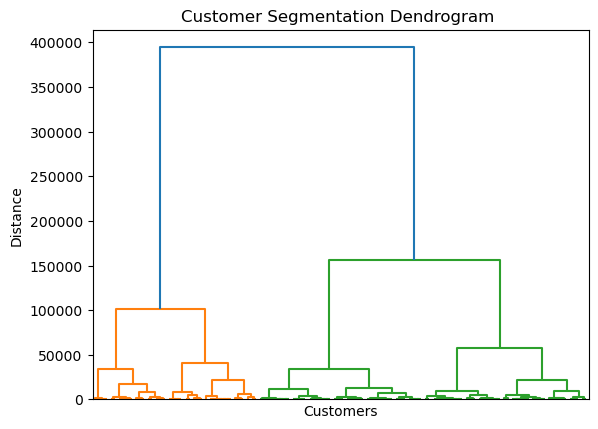

In [8]:
plt.figure()
dendrogram(
    Z,
    no_labels=True
)
plt.title("Customer Segmentation Dendrogram ")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()


In [9]:
hc = AgglomerativeClustering(
    n_clusters=2,
    linkage="ward"
)

df["Cluster"] = hc.fit_predict(X)


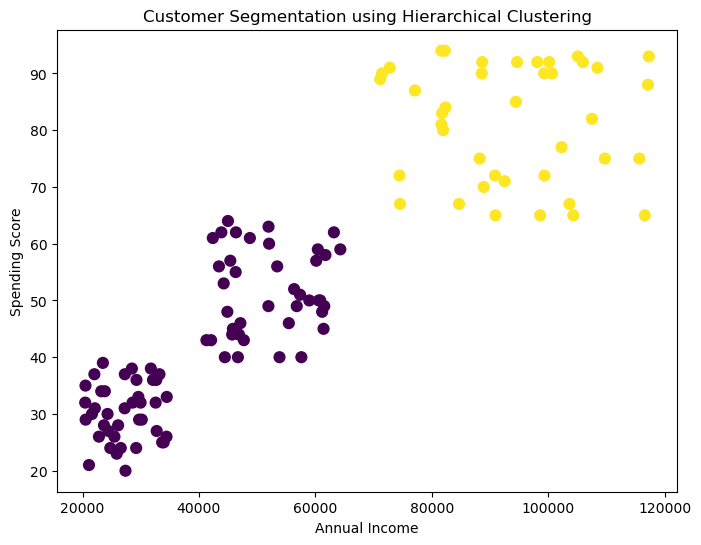

In [10]:
plt.figure(figsize=(8,6))
plt.scatter(
    df["Annual_Income"],
    df["Spending_Score"],
    c=df["Cluster"],
    s=60
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation using Hierarchical Clustering")
plt.show()


In [11]:
df.groupby("Cluster")[["Annual_Income", "Spending_Score"]].mean()

,Annual_Income,Spending_Score
Cluster,,
0,39630.1125,40.925
1,93624.5000,81.375


In [12]:
new_customer = [[55000, 52]]

In [13]:
hc = AgglomerativeClustering(n_clusters=3, linkage="ward")
df["Cluster"] = hc.fit_predict(X)

In [14]:
cluster_centers = df.groupby("Cluster")[["Annual_Income", "Spending_Score"]].mean().values

In [15]:
distances = np.linalg.norm(cluster_centers - new_customer, axis=1)

In [16]:
predicted_cluster = np.argmin(distances)

In [17]:
predicted_cluster

1